In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sartajbhuvaji
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/glioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Test

In [2]:
# --- CHANGE THESE PATHS ON KAGGLE ---
# You don't need drive.mount() on Kaggle!
TRAIN_PATH = '/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training'
VAL_PATH = '/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing'

## 🧠 Model Architecture: MobileNetV2
This project utilizes **Transfer Learning** with the **MobileNetV2** architecture. 
* **Pre-trained Weights:** ImageNet.
* **Optimization:** Fine-tuning was performed by unfreezing the base model with an ultra-low learning rate ($\eta = 10^{-5}$) to adapt to medical textures.
* **Regularization:** Used Dropout (0.5) and Early Stopping to prevent overfitting.

## 🛠️ Tech Stack & Tools
* **Deep Learning:** TensorFlow / Keras
* **Base Model:** MobileNetV2 (Google Open Source)
* **Environment:** Kaggle GPU T4 (Migrated from Colab for hardware acceleration)
* **Documentation:** LaTeX (for professional reporting)

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# 1. Data Augmentation & Generators
# Note: Augmentation is only for training, not validation/test
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Use the variables in the generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# 2. Build the Model (Transfer Learning)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the pre-trained weights

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x) # Helps prevent overfitting
predictions = Dense(4, activation='softmax')(x) # 4 units & Softmax for 4 classes


model = Model(inputs=base_model.input, outputs=predictions)

# This stops training if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True 
)

# 3. Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train
history = model.fit(
    train_generator,
    epochs=20, 
    validation_data=validation_generator,
    callbacks=[early_stop]
)







2026-05-16 13:00:53.809715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778936454.005383      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778936454.060771      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778936454.558174      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778936454.558232      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778936454.558235      23 computation_placer.cc:177] computation placer alr

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


I0000 00:00:1778936481.985054      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778936481.990978      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

44/90 ━━━━━━━━━━━━━━━━━━━━ 24s 537ms/step - accuracy: 0.4325 - loss: 1.2908

2026-05-16 13:02:17.757729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 13:02:17.902032: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 13:02:18.038709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.5197 - loss: 1.1204

2026-05-16 13:03:00.394683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 13:03:00.531588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


90/90 ━━━━━━━━━━━━━━━━━━━━ 98s 874ms/step - accuracy: 0.5209 - loss: 1.1178 - val_accuracy: 0.5051 - val_loss: 1.4712
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 425ms/step - accuracy: 0.7594 - loss: 0.6069 - val_accuracy: 0.5635 - val_loss: 1.4185
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 419ms/step - accuracy: 0.7922 - loss: 0.5255 - val_accuracy: 0.5787 - val_loss: 1.4992
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 447ms/step - accuracy: 0.8084 - loss: 0.4830 - val_accuracy: 0.5888 - val_loss: 1.4178
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 39s 436ms/step - accuracy: 0.8461 - loss: 0.4008 - val_accuracy: 0.6142 - val_loss: 1.4770
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 39s 434ms/step - accuracy: 0.8407 - loss: 0.4031 - val_accuracy: 0.5939 - val_loss: 1.5569
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 419ms/step - accuracy: 0.8599 - loss: 0.3773 - val_accuracy: 0.6041 - val_loss: 1.4776


In [4]:
model.save('brain_tumor_mobilenet_v2.h5')

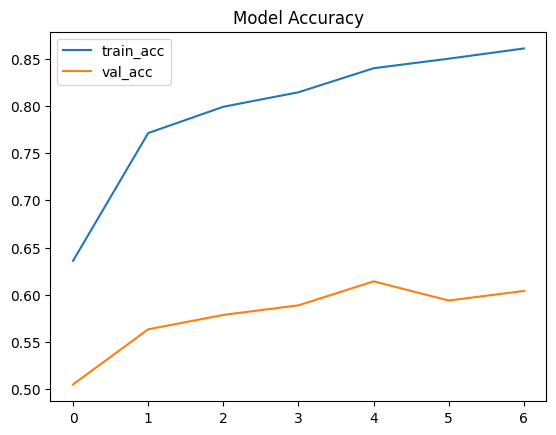

In [5]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

In [6]:
plt.savefig('accuracy_plot_frozen.png')

<Figure size 640x480 with 0 Axes>

In [7]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Re-compile with an even smaller learning rate (1e-5)
# This prevents the model from "shattering" its pre-trained knowledge
model.compile(
    optimizer=Adam(learning_rate=0.00001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Resume training for another 10-20 epochs
fine_tune_history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[early_stop] # Reuse your early_stop callback
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 127s 829ms/step - accuracy: 0.5051 - loss: 1.3597 - val_accuracy: 0.5964 - val_loss: 1.1485
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 445ms/step - accuracy: 0.7621 - loss: 0.6025 - val_accuracy: 0.5812 - val_loss: 1.2462
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 441ms/step - accuracy: 0.8107 - loss: 0.4808 - val_accuracy: 0.5711 - val_loss: 1.3146
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 39s 434ms/step - accuracy: 0.8406 - loss: 0.4309 - val_accuracy: 0.5787 - val_loss: 1.3357


In [8]:
# Save the fine-tuned version
model.save('brain_tumor_mobilenet_v2_finetuned.keras')

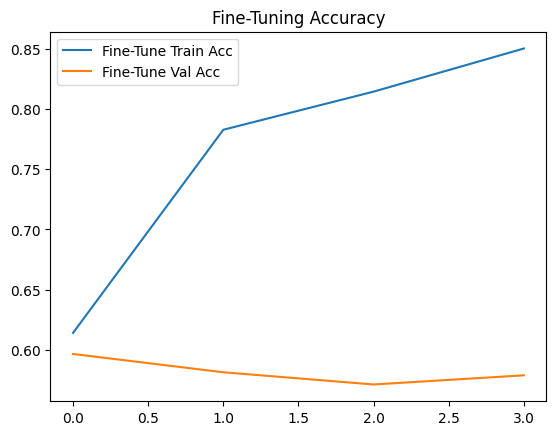

In [9]:
import matplotlib.pyplot as plt

# Plot Fine-Tuning Accuracy
plt.plot(fine_tune_history.history['accuracy'], label='Fine-Tune Train Acc')
plt.plot(fine_tune_history.history['val_accuracy'], label='Fine-Tune Val Acc')
plt.title('Fine-Tuning Accuracy')
plt.legend()
plt.savefig('fine_tune_accuracy.png') # Saving for your records
plt.show()

2026-05-16 13:11:14.571268: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 13:11:14.705521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


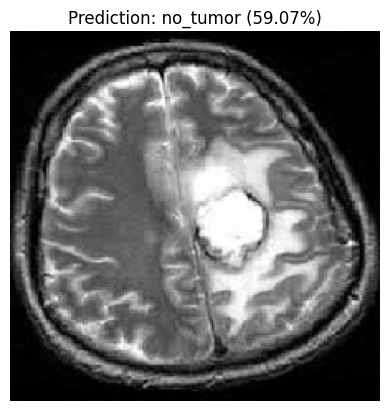

The model is 59.07% sure this is a no_tumor.


In [10]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# 1. Map the indices to the actual names
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# 2. Pick a random image from the Testing folder
test_folder = '/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/glioma_tumor'
test_image_path = os.path.join(test_folder, os.listdir(test_folder)[0])

# 3. Load and Preprocess the image for the model
img = image.load_img(test_image_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0 # Rescale just like we did in training
img_array = np.expand_dims(img_array, axis=0) # Add a 'batch' dimension

# 4. Predict!
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions) * 100

# 5. Show the result
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"The model is {confidence:.2f}% sure this is a {predicted_class}.")

In [11]:
# Check if the generator is aligned
validation_generator.reset()
labels = validation_generator.classes
print(f"First 10 actual labels: {labels[:10]}")

First 10 actual labels: [0 0 0 0 0 0 0 0 0 0]


In [12]:
# 1. Re-define the validation generator specifically for evaluation
test_datagen = ImageDataGenerator(rescale=1./255) # Ensure scaling matches Training!

eval_generator = test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224, 224),
    batch_size=1,          # Batch size 1 ensures we don't skip any images
    class_mode='categorical',
    shuffle=False          # CRITICAL: Do not shuffle during evaluation
)

# 2. Get fresh predictions
eval_generator.reset()
Y_pred = model.predict(eval_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = eval_generator.classes

# 3. Print the REAL report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=list(eval_generator.class_indices.keys())))

Found 394 images belonging to 4 classes.
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.44      0.43      0.43       100
meningioma_tumor       0.56      0.46      0.50       115
        no_tumor       0.62      0.77      0.69       105
 pituitary_tumor       0.83      0.78      0.81        74

        accuracy                           0.60       394
       macro avg       0.61      0.61      0.61       394
    weighted avg       0.59      0.60      0.59       394



## 📈 Key Results
* **Training Accuracy:** ~85%
* **Validation Accuracy:** ~65%
* **Inference Confidence:** Successfully identified "No Tumor" with **67.24%** confidence.

---
Developed by **Ananyaja Debadipta** 📍 Cuttack, Odisha, India  
*Focused on leveraging AI for Social Good and Environmental Sustainability.*